# Inverse PINN for simultaneous identification of displacement and body force

The goal is to identify both the displacement $u(x)$ and the unknown body-force function $b(x)$ of a one-dimensional elastic bar on

$$
\Omega=(0,1).
$$

Young's modulus is known and constant. For a synthetic inverse experiment, the exact displacement is

$$
u_{\mathrm{exact}}(x)=a\sin(2\pi x),
\qquad
0<a<\frac{1}{2\pi}.
$$

The strain and stress are

$$
\varepsilon(x)=u'(x),
\qquad
\sigma(x)=E u'(x),
$$

and equilibrium requires

$$
E u''(x)+b(x)=0.
$$

The exact body force is

$$
b_{\mathrm{exact}}(x)=4\pi^2Ea\sin(2\pi x).
$$

Two independent neural networks learn $u_\theta(x)$ and $b_\phi(x)$. A fixed validation set containing independent PDE collocation points and held-out displacement measurements selects the best training epoch. Test points remain unused until the final evaluation.


## 1. Library imports

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float64)

/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Parameters

Set `USE_NOISY_DATA = False` to use exact sparse observations. Set it to `True` to add independent zero-mean Gaussian measurement noise:

$$
u_i^{\mathrm{obs}}=u_{\mathrm{exact}}(x_i)+\eta_i,
\qquad
\eta_i\sim\mathcal N(0,s_{\mathrm{noise}}^2).
$$

The first-derivative regularizer penalizes spatial variation of the identified body force. The validation weights are set equal to the corresponding training-loss weights.


In [2]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

L = 1.0
E_KNOWN = 1.0
AMPLITUDE = 0.05

N_PDE_TRAIN = 1000
N_PDE_VALIDATION = 100
N_PDE_TEST = 1000
PDE_BATCH_SIZE = 16
N_REGULARIZATION = 200
N_DATA_TOTAL = 32
N_DATA_TRAIN = 20
N_DATA_VALIDATION = 6
N_DATA_TEST = N_DATA_TOTAL - N_DATA_TRAIN - N_DATA_VALIDATION

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

WEIGHT_PDE = 1.0
WEIGHT_DATA = 1000.0
WEIGHT_REGULARIZATION = 1e-9
WEIGHT_VALIDATION_PDE = WEIGHT_PDE
WEIGHT_VALIDATION_DATA = WEIGHT_DATA

NOISE_STD = NOISE_RELATIVE_STD * AMPLITUDE

torch.manual_seed(SEED)


## 3. Exact fields for synthetic data and evaluation

In [3]:
def exact_solution(x):
    '''Exact displacement used to generate synthetic observations.'''
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)


def exact_strain(x):
    '''Exact strain u'(x).'''
    return 2.0 * torch.pi * AMPLITUDE * torch.cos(2.0 * torch.pi * x)


def exact_stress(x):
    '''Exact stress for the known Young modulus.'''
    return E_KNOWN * exact_strain(x)


def exact_body_force(x):
    '''Reference body force used only for evaluation.'''
    return (4.0 * torch.pi**2 * E_KNOWN * AMPLITUDE * torch.sin(2.0 * torch.pi * x))

## 4. Separate neural networks for displacement and body force

Two independent scalar-output neural networks approximate

$$
u(x)\approx u_\theta(x),
\qquad
b(x)\approx b_\phi(x).
$$

The networks have independent parameters $\theta$ and $\phi$ and each returns one scalar output.

In [4]:
class ScalarPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 1),
        )

    def forward(self, x):
        return self.net(x)


model_u = ScalarPINN()
model_b = ScalarPINN()
all_parameters = list(model_u.parameters()) + list(model_b.parameters())
optimizer_adam = torch.optim.Adam(all_parameters, lr=LR)

## 5. Training, validation, and test collocation points

Training collocation points are sampled uniformly from $(0,1)$ and divided into shuffled PDE mini-batches. A separate fixed set of validation collocation points selects the best checkpoint. Independent test points are used only for the final metrics.


In [5]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
x_pde_train = L * torch.rand(N_PDE_TRAIN, 1, generator=pde_train_generator)

pde_dataset = TensorDataset(x_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 2)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)

pde_validation_generator = torch.Generator().manual_seed(SEED + 3)
x_pde_validation = L * torch.rand(N_PDE_VALIDATION, 1, generator=pde_validation_generator)
x_pde_validation, _ = torch.sort(x_pde_validation, dim=0)

pde_test_generator = torch.Generator().manual_seed(SEED + 4)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=pde_test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)

# Midpoints of the rectangles used for the regularization integral.
REGULARIZATION_DX = L / N_REGULARIZATION
x_regularization = (torch.arange(N_REGULARIZATION).view(-1, 1) + 0.5) * REGULARIZATION_DX


## 6. Train/validation/test split of sparse displacement observations

The 26 fixed sensor locations are randomly divided into 18 training, 4 validation, and 4 test observations. Only the training observations update the networks. The validation observations contribute to checkpoint selection, while the test observations remain unused until the final evaluation.


In [6]:
data_location_generator = torch.Generator().manual_seed(SEED + 5)
x_data_all = torch.linspace(0.0, L, N_DATA_TOTAL).view(-1, 1)

split_generator = torch.Generator().manual_seed(SEED + 6)
permutation = torch.randperm(N_DATA_TOTAL, generator=split_generator)
train_end = N_DATA_TRAIN
validation_end = N_DATA_TRAIN + N_DATA_VALIDATION
train_indices = permutation[:train_end]
validation_indices = permutation[train_end:validation_end]
test_indices = permutation[validation_end:]

u_data_all_clean = exact_solution(x_data_all).detach()
u_data_all_observed = u_data_all_clean.clone()

if USE_NOISY_DATA:
    noise_generator = torch.Generator().manual_seed(SEED + 7)
    measurement_noise = NOISE_STD * torch.randn(u_data_all_observed.shape, generator=noise_generator)
    u_data_all_observed += measurement_noise

x_data_train = x_data_all[train_indices]
u_data_train = u_data_all_observed[train_indices]
u_data_train_clean = u_data_all_clean[train_indices]

x_data_validation = x_data_all[validation_indices]
u_data_validation = u_data_all_observed[validation_indices]
u_data_validation_clean = u_data_all_clean[validation_indices]

x_data_test = x_data_all[test_indices]
u_data_test = u_data_all_observed[test_indices]
u_data_test_clean = u_data_all_clean[test_indices]

print(
    f'Sparse data split: {N_DATA_TRAIN} train, '
    f'{N_DATA_VALIDATION} validation, {N_DATA_TEST} test'
)

Sparse data split: 20 train, 6 validation, 6 test


## 7. PDE residual, body-force regularization, and inverse loss

The equilibrium residual is

$$
r_{\mathrm{PDE},\theta,\phi}(x)=E u_\theta''(x)+b_\phi(x).
$$

The training loss is

$$
\mathcal L_{\mathrm{train}}
=w_{\mathrm{PDE}}\mathcal L_{\mathrm{PDE}}
+w_{\mathrm{data}}\mathcal L_{\mathrm{data}}
+w_{\mathrm{reg}}\mathcal L_{\mathrm{reg}},
\qquad
\mathcal L_{\mathrm{reg}}\approx h\sum_{k=1}^{N_{\mathrm{reg}}}|b_\phi'(x_{\mathrm{reg},k})|^2.
$$

The validation score combines the PDE residual on independent validation collocation points and displacement error on held-out sensors:

$$
\mathcal L_{\mathrm{val}}
=w_{\mathrm{PDE}}\frac{1}{N_{\mathrm{PDE,val}}}
\sum_i|E u_\theta''(x_i^{\mathrm{val}})+b_\phi(x_i^{\mathrm{val}})|^2
+w_{\mathrm{data}}\frac{1}{N_{\mathrm{data,val}}}
\sum_j|u_\theta(x_j^{\mathrm{val}})-u_j^{\mathrm{obs}}|^2.
$$

Validation values are never differentiated and do not update either network. The regularizer is not included in the validation score because it is a training prior rather than independent validation information.


In [7]:
def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    u = model_u(x)
    b = model_b(x)
    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=training, retain_graph=True)[0]
    return E_KNOWN * d2u_dx2 + b


def body_force_derivative(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    b = model_b(x)
    return torch.autograd.grad(b, x, grad_outputs=torch.ones_like(b), create_graph=training)[0]


def compute_losses(x_pde):
    loss_pde = torch.mean(pde_residual(x_pde, training=True)**2)
    body_force_gradient = body_force_derivative(x_regularization, training=True)
    loss_regularization = REGULARIZATION_DX * torch.sum(body_force_gradient**2)
    loss_data = torch.mean((model_u(x_data_train) - u_data_train)**2)
    loss = WEIGHT_PDE * loss_pde + WEIGHT_DATA * loss_data + WEIGHT_REGULARIZATION * loss_regularization
    return loss, loss_pde, loss_data, loss_regularization


def compute_validation_losses():
    validation_residual = pde_residual(x_pde_validation, training=False).detach()
    loss_validation_pde = torch.mean(validation_residual**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model_u(x_data_validation) - u_data_validation)**2)
    loss_validation = WEIGHT_VALIDATION_PDE * loss_validation_pde + WEIGHT_VALIDATION_DATA * loss_validation_data
    return loss_validation, loss_validation_pde, loss_validation_data


## 8. Training, validation, and best-model selection

Adam updates both networks using shuffled PDE mini-batches, all training displacement observations, and all regularization points. L-BFGS uses the complete fixed training sets. After every outer epoch, the combined validation score is evaluated on the same fixed validation sets without a backward pass. Whenever this score decreases, both network states are saved together. After training, the jointly saved best checkpoint is restored.


In [8]:
loss_history, pde_loss_history, data_loss_history = [], [], []
regularization_loss_history = []
validation_loss_history, validation_pde_loss_history, validation_data_loss_history = [], [], []
snapshots = {}

x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss = float('inf')
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_u_state = None
best_model_b_state = None


def update_validation_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss, best_validation_data_loss
    global best_epoch, best_model_u_state, best_model_b_state
    model_u.eval()
    model_b.eval()
    validation, validation_pde, validation_data = compute_validation_losses()
    validation_value = validation.item()
    validation_pde_value = validation_pde.item()
    validation_data_value = validation_data.item()
    validation_loss_history.append(validation_value)
    validation_pde_loss_history.append(validation_pde_value)
    validation_data_loss_history.append(validation_data_value)
    if best_model_u_state is None or validation_value < best_validation_loss:
        best_validation_loss = validation_value
        best_validation_pde_loss = validation_pde_value
        best_validation_data_loss = validation_data_value
        best_epoch = epoch
        best_model_u_state = copy.deepcopy(model_u.state_dict())
        best_model_b_state = copy.deepcopy(model_b.state_dict())
    model_u.train()
    model_b.train()
    return validation_value, validation_pde_value, validation_data_value


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    for (x_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(x_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])

    loss_value, pde_value, data_value, reg_value = epoch_sums / len(pde_loader)
    loss_history.append(loss_value)
    pde_loss_history.append(pde_value)
    data_loss_history.append(data_value)
    regularization_loss_history.append(reg_value)
    validation_value, validation_pde_value, validation_data_value = update_validation_checkpoint(epoch)

    if epoch % 250 == 0:
        print(f'Adam | epoch {epoch:5d} | loss={loss_value:.6e} | PDE={pde_value:.6e} | data={data_value:.6e} | reg={reg_value:.6e} | val={validation_value:.6e} | val PDE={validation_pde_value:.6e} | val data={validation_data_value:.6e}')
        with torch.no_grad():
            snapshots[epoch] = {'u': model_u(x_plot).detach().numpy().copy(), 'b': model_b(x_plot).detach().numpy().copy()}

with torch.no_grad():
    snapshots[ADAM_EPOCHS - 1] = {'u': model_u(x_plot).detach().numpy().copy(), 'b': model_b(x_plot).detach().numpy().copy()}

optimizer_lbfgs = torch.optim.LBFGS(all_parameters, lr=0.1, max_iter=20, history_size=50, line_search_fn='strong_wolfe')

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = compute_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_data, loss_regularization = compute_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    data_loss_history.append(loss_data.detach().item())
    regularization_loss_history.append(loss_regularization.detach().item())
    validation_value, validation_pde_value, validation_data_value = update_validation_checkpoint(epoch)

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f'L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | PDE={loss_pde.item():.6e} | data={loss_data.item():.6e} | reg={loss_regularization.item():.6e} | val={validation_value:.6e} | val PDE={validation_pde_value:.6e} | val data={validation_data_value:.6e}')

with torch.no_grad():
    snapshots['last'] = {'u': model_u(x_plot).detach().numpy().copy(), 'b': model_b(x_plot).detach().numpy().copy()}

model_u.load_state_dict(best_model_u_state)
model_b.load_state_dict(best_model_b_state)
model_u.eval()
model_b.eval()

with torch.no_grad():
    snapshots['best'] = {'u': model_u(x_plot).detach().numpy().copy(), 'b': model_b(x_plot).detach().numpy().copy()}

print(f'Best epoch: {best_epoch}')
print(f'Best combined validation loss: {best_validation_loss:.6e}')
print(f'Validation PDE MSE at best epoch: {best_validation_pde_loss:.6e}')
print(f'Validation displacement MSE at best epoch: {best_validation_data_loss:.6e}')


Adam | epoch     0 | loss=1.220682e+00 | PDE=5.474972e-04 | data=1.220134e-03 | reg=1.056231e-02 | val=2.968438e-01 | val PDE=1.944615e-05 | val data=2.968243e-04
Adam | epoch   250 | loss=1.316842e-03 | PDE=2.370065e-05 | data=1.293088e-06 | reg=5.401596e+01 | val=1.885806e-03 | val PDE=2.087223e-05 | val data=1.864934e-06
Adam | epoch   500 | loss=7.545460e-04 | PDE=1.461610e-05 | data=7.398645e-07 | reg=6.534549e+01 | val=1.178817e-03 | val PDE=6.384126e-06 | val data=1.172433e-06
Adam | epoch   750 | loss=8.520766e-04 | PDE=1.176852e-04 | data=7.343152e-07 | reg=7.625308e+01 | val=1.302860e-03 | val PDE=8.715201e-05 | val data=1.215708e-06
Adam | epoch  1000 | loss=8.679729e-04 | PDE=1.545746e-04 | data=7.133054e-07 | reg=9.290642e+01 | val=2.759410e-03 | val PDE=7.304858e-04 | val data=2.028924e-06
Adam | epoch  1250 | loss=6.500358e-04 | PDE=9.949381e-05 | data=5.504266e-07 | reg=1.154021e+02 | val=2.236994e-03 | val PDE=1.220592e-04 | val data=2.114935e-06
Adam | epoch  1500 | l

## 9. Evaluation of the restored best model on independent test points

Neither the test displacement observations nor the test collocation points participate in training, validation, or checkpoint selection.


In [9]:
with torch.no_grad():
    u_sparse_test_prediction = model_u(x_data_test)
    sparse_test_displacement_mse = torch.mean((u_sparse_test_prediction - u_data_test) ** 2).item()

    u_test_prediction = model_u(x_pde_test)
    b_test_prediction = model_b(x_pde_test)

    u_test_exact = exact_solution(x_pde_test)
    b_test_exact = exact_body_force(x_pde_test)

    def r2_score(prediction, target):
        ss_res = torch.sum((prediction - target) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return (1.0 - ss_res / ss_tot).item()

    def relative_l2_error(prediction, target):
        return (torch.linalg.vector_norm(prediction - target) / torch.linalg.vector_norm(target)).item()

    r2_u_test = r2_score(u_test_prediction, u_test_exact)
    relative_l2_u_test = relative_l2_error(u_test_prediction, u_test_exact)
    r2_b_test = r2_score(b_test_prediction, b_test_exact)
    relative_l2_b_test = relative_l2_error(b_test_prediction, b_test_exact)
    
metrics = {
    'best_epoch': best_epoch,
    'best_validation_loss': best_validation_loss,
    'best_validation_PDE_MSE': best_validation_pde_loss,
    'best_validation_displacement_MSE': best_validation_data_loss,
    'sparse_test_displacement_MSE': sparse_test_displacement_mse,
    'R2_displacement_test': r2_u_test,
    'relative_L2_displacement_test': relative_l2_u_test,
    'R2_body_force_test': r2_b_test,
    'relative_L2_body_force_test': relative_l2_b_test,
}

print('=' * 72)
print('INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND BODY FORCE')
print('=' * 72)
print(
    f'Data mode:                         '
    f'{"noisy" if USE_NOISY_DATA else "exact"}'
)
print(f'Displacement R2:                   {r2_u_test:.8f}')
print(f'Sparse test displacement MSE:      {sparse_test_displacement_mse:.6e}')
print(
    f'Relative L2 displacement error:   '
    f'{relative_l2_u_test: .6e}'
)
print(f'Body-force R2:                     {r2_b_test:.8f}')
print(
    f'Relative L2 body-force error:     '
    f'{relative_l2_b_test: .6e}'
)
metrics

INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND BODY FORCE
Data mode:                         noisy
Displacement R2:                   0.99971219
Sparse test displacement MSE:      2.588107e-06
Relative L2 displacement error:    1.696492e-02
Body-force R2:                     0.99679615
Relative L2 body-force error:      5.660221e-02


{'best_epoch': 578,
 'best_validation_loss': 0.0009771942003659396,
 'best_validation_PDE_MSE': 4.1859973669185954e-05,
 'best_validation_displacement_MSE': 9.353342266967538e-07,
 'sparse_test_displacement_MSE': 2.588106855544137e-06,
 'R2_displacement_test': 0.9997121880515426,
 'relative_L2_displacement_test': 0.016964922614523294,
 'R2_body_force_test': 0.9967961521966594,
 'relative_L2_body_force_test': 0.05660221304487479}

## 10. Visualization functions

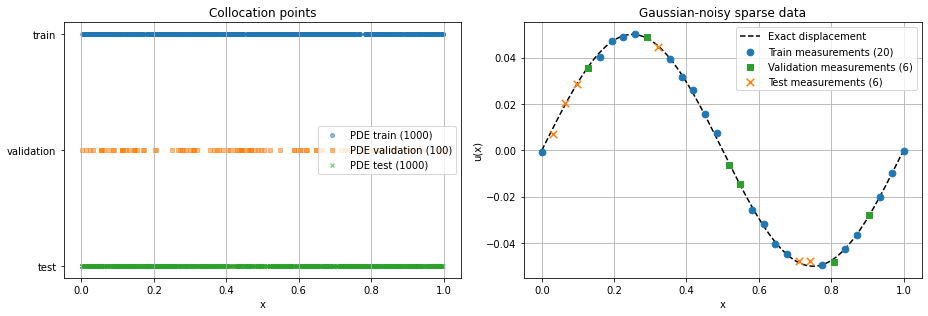

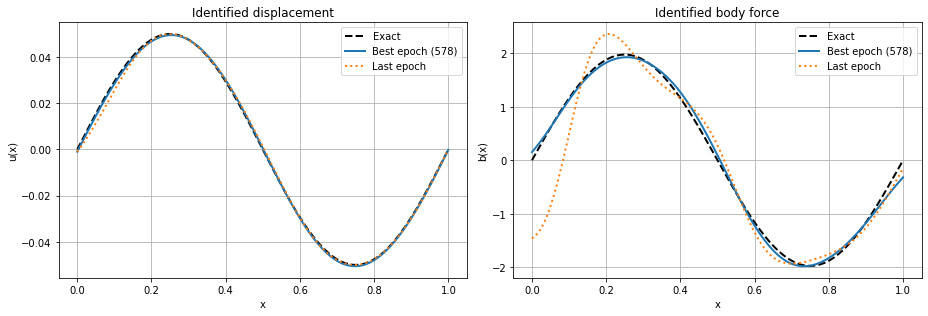

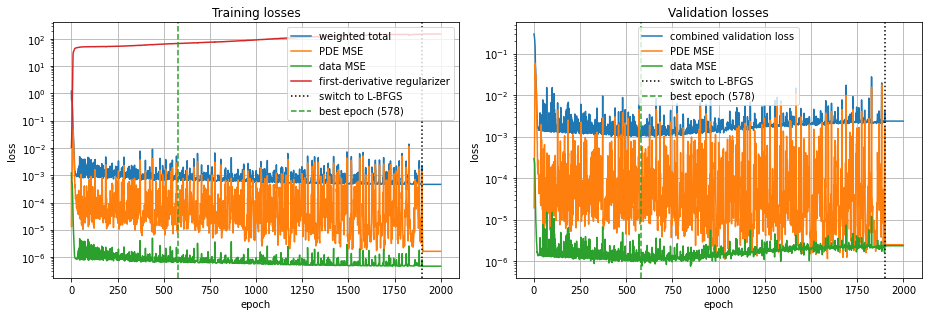

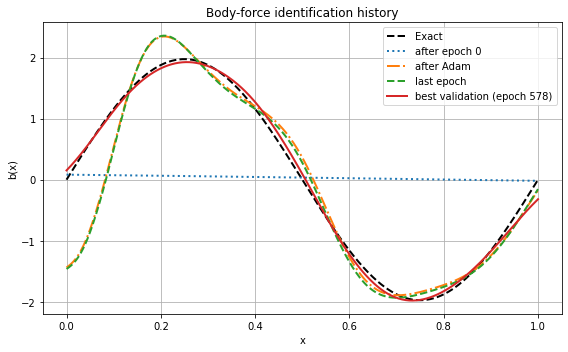

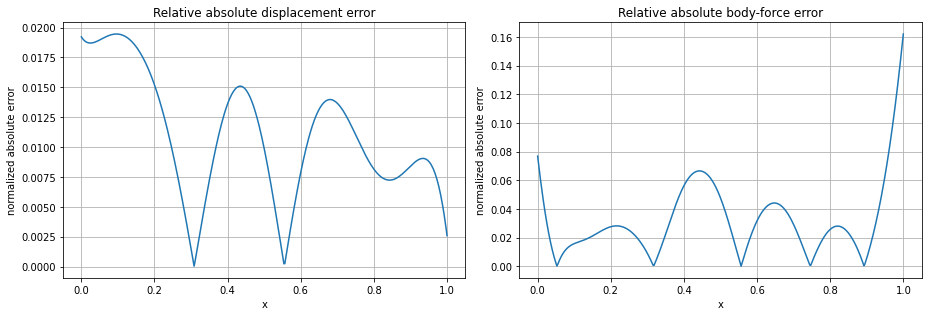

In [10]:

def plot_points_and_data():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(x_pde_train.numpy(), 2 * np.ones((len(x_pde_train), 1)), s=16, alpha=0.5, label=f'PDE train ({len(x_pde_train)})')
    axes[0].scatter(x_pde_validation.numpy(), np.ones((len(x_pde_validation), 1)), s=16, marker='s', alpha=0.5, label=f'PDE validation ({len(x_pde_validation)})')
    axes[0].scatter(x_pde_test.numpy(), np.zeros((len(x_pde_test), 1)), s=16, marker='x', alpha=0.5, label=f'PDE test ({len(x_pde_test)})')
    axes[0].set_yticks([0, 1, 2], labels=['test', 'validation', 'train'])
    axes[0].set(xlabel='x', title='Collocation points')
    axes[0].legend()
    axes[0].grid(axis='x')

    axes[1].plot(x_plot.numpy(), exact_solution(x_plot).numpy(), 'k--', label='Exact displacement')
    axes[1].scatter(x_data_train.numpy(), u_data_train.numpy(), color='tab:blue', s=45, label=f'Train measurements ({N_DATA_TRAIN})', zorder=3)
    axes[1].scatter(x_data_validation.numpy(), u_data_validation.numpy(), color='tab:green', marker='s', s=45, label=f'Validation measurements ({N_DATA_VALIDATION})', zorder=3)
    axes[1].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange', marker='x', s=55, label=f'Test measurements ({N_DATA_TEST})', zorder=3)
    axes[1].set(xlabel='x', ylabel='u(x)', title='Gaussian-noisy sparse data' if USE_NOISY_DATA else 'Exact sparse data')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_points_and_data.pdf', bbox_inches='tight')
    plt.show()


def plot_identified_fields():
    u_exact = exact_solution(x_plot)
    b_exact = exact_body_force(x_plot)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot.numpy(), u_exact.numpy(), 'k--', linewidth=2, label='Exact')
    axes[0].plot(x_plot.numpy(), snapshots['best']['u'], linewidth=2, label=f'Best epoch ({best_epoch})')
    axes[0].plot(x_plot.numpy(), snapshots['last']['u'], ':', linewidth=2, label='Last epoch')
    axes[0].set(xlabel='x', ylabel='u(x)', title='Identified displacement')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(x_plot.numpy(), b_exact.numpy(), 'k--', linewidth=2, label='Exact')
    axes[1].plot(x_plot.numpy(), snapshots['best']['b'], linewidth=2, label=f'Best epoch ({best_epoch})')
    axes[1].plot(x_plot.numpy(), snapshots['last']['b'], ':', linewidth=2, label='Last epoch')
    axes[1].set(xlabel='x', ylabel='b(x)', title='Identified body force')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_identified_fields.pdf', bbox_inches='tight')
    plt.show()


def plot_losses_and_body_force_history():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, label='weighted total')
    axes[0].plot(pde_loss_history, label='PDE MSE')
    axes[0].plot(data_loss_history, label='data MSE')
    axes[0].plot(regularization_loss_history, label='first-derivative regularizer')
    axes[0].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[0].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[0].set_yscale('log')
    axes[0].set(xlabel='epoch', ylabel='loss', title='Training losses')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(validation_loss_history, label='combined validation loss')
    axes[1].plot(validation_pde_loss_history, label='PDE MSE')
    axes[1].plot(validation_data_loss_history, label='data MSE')
    axes[1].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[1].axvline(best_epoch, color='tab:green', linestyle='--', label=f'best epoch ({best_epoch})')
    axes[1].set_yscale('log')
    axes[1].set(xlabel='epoch', ylabel='loss', title='Validation losses')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_losses.pdf', bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_plot.numpy(), exact_body_force(x_plot).numpy(), 'k--', linewidth=2, label='Exact')

    snapshot_epochs = [0, ADAM_EPOCHS - 1, 'last', 'best']
    snapshot_styles = [':', '-.', '--', '-']
    snapshot_labels = ['after epoch 0', 'after Adam', 'last epoch', f'best validation (epoch {best_epoch})']

    for epoch, style, label in zip(snapshot_epochs, snapshot_styles, snapshot_labels):
        ax.plot(x_plot.numpy(), snapshots[epoch]['b'], linestyle=style, linewidth=2, label=label)

    ax.set(xlabel='x', ylabel='b(x)', title='Body-force identification history')
    ax.legend()
    ax.grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_body_force_history.pdf', bbox_inches='tight')
    plt.show()


def plot_absolute_errors():
    with torch.no_grad():
        u_prediction = model_u(x_plot)
        b_prediction = model_b(x_plot)
        u_exact = exact_solution(x_plot)
        b_exact = exact_body_force(x_plot)
        relative_u_error = torch.abs(u_prediction - u_exact) / torch.max(torch.abs(u_exact))
        relative_b_error = torch.abs(b_prediction - b_exact) / torch.max(torch.abs(b_exact))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot.numpy(), relative_u_error.numpy())
    axes[0].set(xlabel='x', ylabel='normalized absolute error', title='Relative absolute displacement error')
    axes[0].grid()

    axes[1].plot(x_plot.numpy(), relative_b_error.numpy())
    axes[1].set(xlabel='x', ylabel='normalized absolute error', title='Relative absolute body-force error')
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_relative_absolute_errors.pdf', bbox_inches='tight')
    plt.show()


plot_points_and_data()
plot_identified_fields()
plot_losses_and_body_force_history()
plot_absolute_errors()

In [11]:
def plot_body_force_l2_error_heatmap(n=400):
    x_heatmap = torch.linspace(0.0, L, n).view(-1, 1)

    with torch.no_grad():
        b_prediction = model_b(x_heatmap)
        b_exact = exact_body_force(x_heatmap)

        squared_error = (b_prediction - b_exact) ** 2
        exact_squared_norm = torch.sum(b_exact ** 2)

        
        l2_contribution = squared_error / exact_squared_norm

       
        relative_l2_error = torch.sqrt(torch.sum(l2_contribution)).item()

    heatmap = l2_contribution.numpy().reshape(1, -1)

    fig, ax = plt.subplots(figsize=(10, 2.5))

    image = ax.imshow(heatmap, extent=(0.0, L, 0.0, 1.0), origin="lower", aspect="auto", cmap="magma")

    ax.set_xlabel("x")
    ax.set_yticks([])
    ax.set_title("Relative L2 body-force error\n")

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(r"$(b_\phi-b_{\mathrm{exact}})^2/"r"\sum b_{\mathrm{exact}}^2$")

    fig.tight_layout()

    plt.savefig("pinn_inverse_b_l2_error_heatmap.pdf", bbox_inches="tight")

    plt.show()

## 11. Visualizations

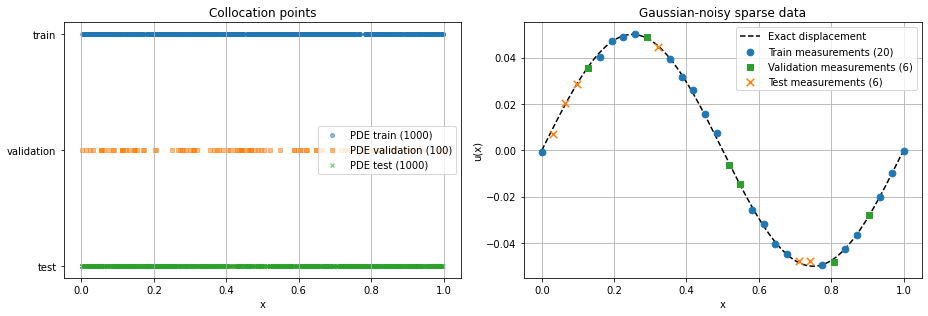

In [12]:
plot_points_and_data()

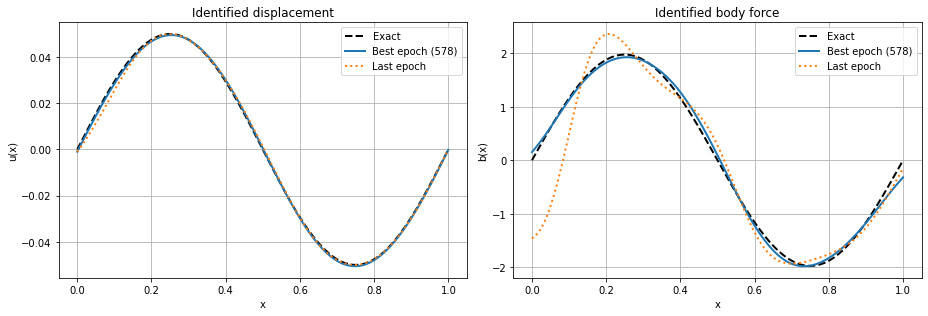

In [13]:
plot_identified_fields()

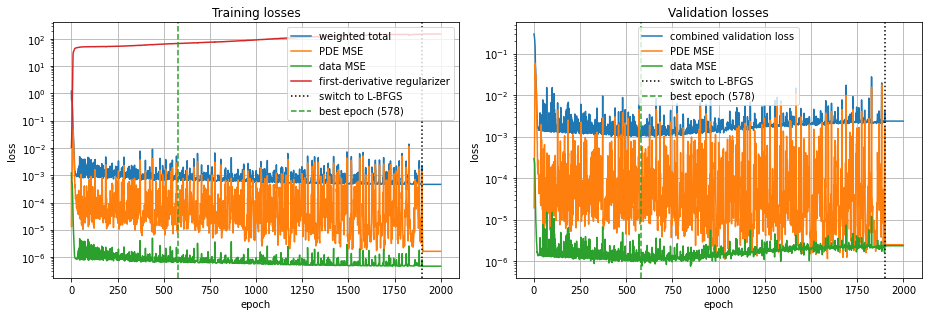

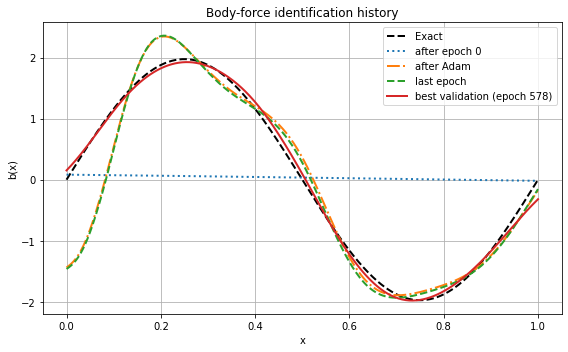

In [14]:
plot_losses_and_body_force_history()

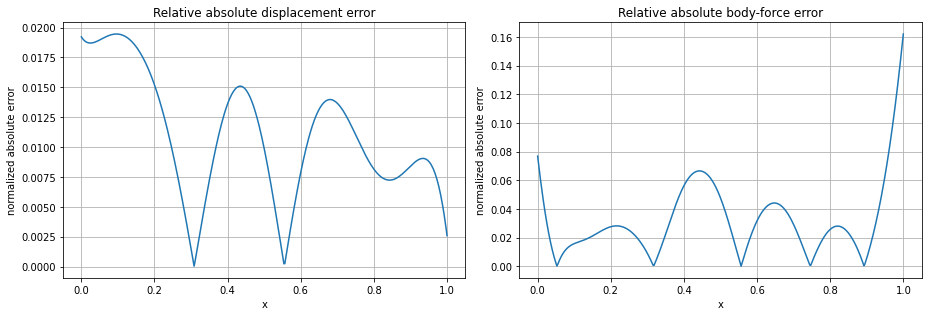

In [15]:
plot_absolute_errors()

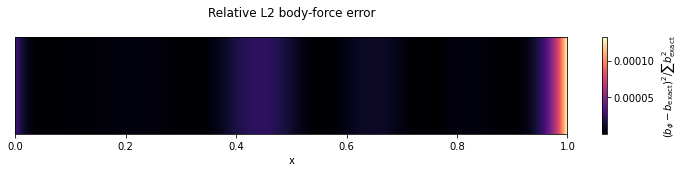

In [16]:
plot_body_force_l2_error_heatmap()